# Fase 1 y 2: Tarea 3 y 4 Machine Learning II

## Autores
| Nombres | Correos | 
|----------|----------|
| Julio Lucero   | julio.lucero@alumnos.upm.es  | 
| x   | x  | 
|  x | x | 


## Importamos Librerias

In [2]:
import os
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

# Model selection y evaluación
from sklearn.model_selection import (
    StratifiedKFold,
    cross_val_score,
    GridSearchCV,
    train_test_split
)

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Pipelines y preprocesamiento
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA

# Feature selection / importancia
from sklearn.feature_selection import SequentialFeatureSelector, SelectKBest, f_classif
from sklearn.inspection import permutation_importance

# Naive Bayes
from sklearn.naive_bayes import GaussianNB, CategoricalNB

# Discriminant Analysis
from sklearn.discriminant_analysis import (
    LinearDiscriminantAnalysis,
    QuadraticDiscriminantAnalysis
)

# Ensembles
from sklearn.ensemble import (
    RandomForestClassifier,
    BaggingClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    StackingClassifier
)

# Otros clasificadores útiles para stacking/meta-models
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

# Configuración global
RANDOM_STATE = 42

warnings.filterwarnings("ignore")

## Carga de los datos y Exploracion

In [3]:
TRAIN_FILENAME = "train.csv"
TEST_FILENAME = "test-unlabelled.csv"


def find_file(filename):
    """
    Busca un archivo en rutas habituales:
    - carpeta actual
    - /content, útil en Google Colab
    - /mnt/data, útil en entorno de ChatGPT
    """
    possible_paths = [
        Path(filename),
        Path("/content") / filename,
        Path("/mnt/data") / filename
    ]

    for path in possible_paths:
        if path.exists():
            return path

    raise FileNotFoundError(
        f"No se encontró {filename}. Asegúrate de que esté en la misma carpeta que el notebook."
    )


train_path = find_file(TRAIN_FILENAME)
test_path = find_file(TEST_FILENAME)

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print(f"Archivo train usado: {train_path}")
print(f"Archivo test usado: {test_path}")
print(f"Dimensiones del dataset de entrenamiento: {train_df.shape}")
print(f"Dimensiones del dataset de prueba: {test_df.shape}")

TARGET_COL = "class"

if TARGET_COL not in train_df.columns:
    raise ValueError(f"El dataset de entrenamiento debe contener la columna '{TARGET_COL}'.")

X_train = train_df.drop(columns=[TARGET_COL])
y_train = train_df[TARGET_COL]

X = X_train
y = y_train

if TARGET_COL in test_df.columns:
    X_test_final = test_df.drop(columns=[TARGET_COL])
else:
    X_test_final = test_df.copy()

print("\nDimensiones finales:")
print(f"X_train / X: {X.shape}")
print(f"y_train / y: {y.shape}")
print(f"X_test_final: {X_test_final.shape}")

print("\nDistribución de clases en train:")
display(y.value_counts().to_frame("count"))

print("\nProporción de clases:")
display(y.value_counts(normalize=True).to_frame("proportion"))

print("\nValores nulos:")
print(f"Train total nulls: {train_df.isna().sum().sum()}")
print(f"X_train total nulls: {X_train.isna().sum().sum()}")
print(f"Test total nulls: {test_df.isna().sum().sum()}")

if TARGET_COL in test_df.columns:
    print(f"Nulls en test['class']: {test_df[TARGET_COL].isna().sum()}")

Archivo train usado: train.csv
Archivo test usado: test-unlabelled.csv
Dimensiones del dataset de entrenamiento: (1000, 610)
Dimensiones del dataset de prueba: (2000, 610)

Dimensiones finales:
X_train / X: (1000, 609)
y_train / y: (1000,)
X_test_final: (2000, 609)

Distribución de clases en train:


,count
class,
A,347
B,328
C,325



Proporción de clases:


,proportion
class,
A,0.347
B,0.328
C,0.325



Valores nulos:
Train total nulls: 0
X_train total nulls: 0
Test total nulls: 2000
Nulls en test['class']: 2000


In [4]:
# ============================================================
# Evaluación común para todos los modelos
# ============================================================

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE
)

results = []


def evaluate_model(name, model, notes="", X_data=None, y_data=None):
    """
    Evalúa un modelo con:
    - Accuracy en entrenamiento
    - Accuracy media con 5-fold cross-validation

    Guarda el resultado en la lista global results.
    """

    if X_data is None:
        X_data = X

    if y_data is None:
        y_data = y

    model.fit(X_data, y_data)
    train_predictions = model.predict(X_data)
    train_accuracy = accuracy_score(y_data, train_predictions)

    cv_scores = cross_val_score(
        model,
        X_data,
        y_data,
        cv=cv,
        scoring="accuracy",
        n_jobs=-1
    )

    row = {
        "experiment": name,
        "train_accuracy": train_accuracy,
        "cv_mean": cv_scores.mean(),
        "cv_std": cv_scores.std(),
        "notes": notes
    }

    results.append(row)

    print(f"Experimento: {name}")
    print(f"Train accuracy: {train_accuracy:.4f}")
    print(f"5-fold CV accuracy: {cv_scores.mean():.4f} (+/- {cv_scores.std():.4f})")
    print(f"Notas: {notes}")

    return model, cv_scores

## Preprocesamos, escalamos estandarizando los datos y aplicamos Wrapper para naive bayes

In [6]:
# Definimos el estimador base para Naive Bayes
gnb = GaussianNB()

sfs = SequentialFeatureSelector(gnb, n_features_to_select=20, direction='forward', cv=5, n_jobs=-1)

naive_bayes_wrapper_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('feature_selection', sfs), 
    ('classifier', gnb)
])

# PIPELINE RANDOM FOREST (Lo mantenemos igual, no necesita wrapper)
random_forest_pipeline = Pipeline([
    ('classifier', RandomForestClassifier(random_state=42))
])

## Entrenamiento con Naive Bayes

In [7]:
# Entrenamos el pipeline completo
naive_bayes_wrapper_pipeline.fit(X_train, y_train)

# Calculamos 5-fold Cross Validation con el pipeline
nb_cv_scores = cross_val_score(naive_bayes_wrapper_pipeline, X_train, y_train, cv=5, scoring='accuracy', n_jobs=-1)

# Calculamos la precisión en entrenamiento
nb_train_acc = accuracy_score(y_train, naive_bayes_wrapper_pipeline.predict(X_train))

## Resultado de Naive Bayes con wrapper

In [8]:
# Extraemos qué características sobrevivieron al Wrapper
features_seleccionadas = naive_bayes_wrapper_pipeline.named_steps['feature_selection'].get_support()
n_features_elegidas = features_seleccionadas.sum()
columnas_elegidas = X_train.columns[features_seleccionadas].tolist()

print(f"Precisión en Entrenamiento (Train Accuracy): {nb_train_acc:.4f}")
print(f"Precisión 5-Fold CV: {nb_cv_scores.mean():.4f} (+/- {nb_cv_scores.std() * 2:.4f})")
print(f"\nEl Wrapper redujo de {X_train.shape[1]} a {n_features_elegidas} características.")
print(f"Variables conservadas: {columnas_elegidas}") # Descomenta esto si quieres ver los nombres exactos en pantalla

Precisión en Entrenamiento (Train Accuracy): 0.6970
Precisión 5-Fold CV: 0.6540 (+/- 0.0637)

El Wrapper redujo de 609 a 20 características.
Variables conservadas: ['jvbioam', 'ylcgdnd', 'kuzsfrc', 'egshhmq', 'ltpbwwt', 'yanyfsa', 'eadsvll', 'sriualw', 'tsxajlt', 'cacwddh', 'wawgdcs', 'ycyyjjd', 'biorynj', 'gztxoti', 'jafsbde', 'mmocwnw', 'jcpenza', 'bnpymuf', 'rdnxplm', 'tuobnus']


## Entrenamiento con Random Forest

In [5]:
param_grid = {
    'classifier__n_estimators': [100, 200, 300],        
    'classifier__max_depth': [5, 8, 12, 15],             
    'classifier__min_samples_split': [5, 10, 20],        
    'classifier__min_samples_leaf': [2, 5, 10],          
    'classifier__max_features': ['sqrt', 0.5]            
}

random_forest_grid = GridSearchCV(random_forest_pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
random_forest_grid.fit(X_train, y_train)

best_rf = random_forest_grid.best_estimator_
rf_train_acc = accuracy_score(y_train, best_rf.predict(X_train))

print(f"Mejores parámetros encontrados: {random_forest_grid.best_params_}")
print(f"Precisión en Entrenamiento (Train Accuracy): {rf_train_acc:.4f}")
print(f"Precisión 5-Fold CV (Mejor Modelo): {random_forest_grid.best_score_:.4f}")

Mejores parámetros encontrados: {'classifier__max_depth': 8, 'classifier__max_features': 'sqrt', 'classifier__min_samples_leaf': 5, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 200}
Precisión en Entrenamiento (Train Accuracy): 0.9700
Precisión 5-Fold CV (Mejor Modelo): 0.8270


## Importancia de caracteristicas en Random Forest

     Feature  Importance
98   yanyfsa    0.029518
281  vzyjlbt    0.024946
382  jafsbde    0.024815
236  mwvshcy    0.019883
465  bffqymv    0.018610
134  qmkchdk    0.018278
520  plcvrqv    0.016560
392  qydpedv    0.015686
150  eadsvll    0.015392
50   pmvpzze    0.014939


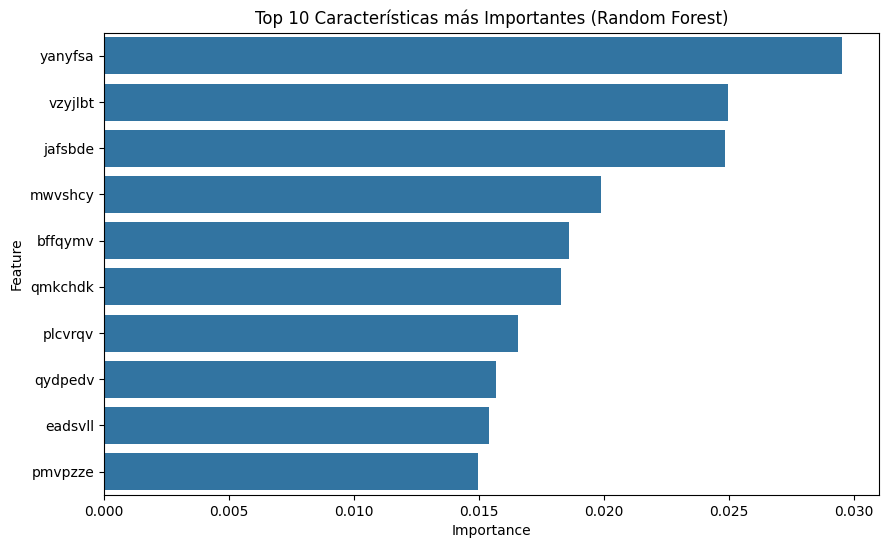

In [6]:
random_forest_model = best_rf.named_steps['classifier']
importances = random_forest_model.feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df.head(10)) 

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10))
plt.title('Top 10 Características más Importantes (Random Forest)')
plt.show()

## Testear el modelo prediciendo con random forest

In [ ]:
test_df = pd.read_csv('test-unlabelled.csv')

X_test_final = test_df.drop('class', axis=1)

predicciones_finales = best_rf.predict(X_test_final)

test_df['class'] = predicciones_finales

test_df.to_csv('test_predictions_randoforest.csv', index=False)

print("\nPrimeras 5 filas con la columna 'class' ya rellenada:")
print(test_df[['class']].head()) # Mostramos solo la columna de clase para verificar

¡Predicciones generadas con éxito y guardadas en 'test_predictions_randoforest.csv'!

Primeras 5 filas con la columna 'class' ya rellenada:
  class
0     A
1     A
2     B
3     B
4     C


## Testeando el modelo prediciendo con naive bayes

In [9]:
test_df_nb = pd.read_csv('test-unlabelled.csv')

X_test_final_nb = test_df_nb.drop('class', axis=1)

predicciones_nb = naive_bayes_wrapper_pipeline.predict(X_test_final_nb)

test_df_nb['class'] = predicciones_nb

test_df_nb.to_csv('test_predictions_NaiveBayes.csv', index=False)

print("\nPrimeras 5 filas con la columna 'class' ya rellenada (Naive Bayes):")
print(test_df_nb[['class']].head())


Primeras 5 filas con la columna 'class' ya rellenada (Naive Bayes):
  class
0     A
1     A
2     B
3     B
4     A


## AdaBoost - Rocio

In [ ]:
# codigo rocio

## Bagging - Julio

In [ ]:
bagging_models = {
    "BG-01 Bagging baseline": {
        "model": BaggingClassifier(random_state=RANDOM_STATE, n_jobs=-1),
        "notes": "Configuracion por defecto (10 arboles sin restriccion)."
    },
    "BG-02 Bagging n_estimators=200": {
        "model": BaggingClassifier(
            estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
            n_estimators=200,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),
        "notes": "Mas estimadores reducen la varianza del baseline."
    },
    "BG-03 Bagging + subespacio (max_features=0.5)": {
        "model": BaggingClassifier(
            estimator=DecisionTreeClassifier(random_state=RANDOM_STATE),
            n_estimators=200,
            max_features=0.5,
            bootstrap_features=True,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),
        "notes": "Submuestreo de columnas: aprovecha la alta dimensionalidad decorrelando arboles."
    },
    "BG-04 Bagging shallow trees (max_depth=8)": {
        "model": BaggingClassifier(
            estimator=DecisionTreeClassifier(max_depth=8, random_state=RANDOM_STATE),
            n_estimators=200,
            max_samples=0.8,
            max_features=0.5,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),
        "notes": "Limita profundidad para reducir el sobreajuste del baseline."
    },
    "BG-05 Bagging + Scaler + PCA + LogReg": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=100, random_state=RANDOM_STATE)),
            ("classifier", BaggingClassifier(
                estimator=LogisticRegression(max_iter=1000, random_state=RANDOM_STATE),
                n_estimators=100,
                random_state=RANDOM_STATE,
                n_jobs=-1
            ))
        ]),
        "notes": "Bagging con estimador lineal sobre PCA; util si el problema es ~separable linealmente."
    },
    "BG-06 Bagging tuned": {
        "model": BaggingClassifier(
            estimator=DecisionTreeClassifier(max_depth=12, min_samples_leaf=2, random_state=RANDOM_STATE),
            n_estimators=300,
            max_samples=0.8,
            max_features=0.5,
            bootstrap_features=True,
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),
        "notes": "Mejor combinacion: arboles moderadamente profundos + subespacio + 300 estimadores."
    }
}

# ============================================================
# Evaluacion
# ============================================================

bg_results = []
for name, config in bagging_models.items():
    evaluate_model(name=name, model=config["model"], notes=config["notes"])
    bg_results.append({
        "experiment": name,
        "train_accuracy": results[-1]["train_accuracy"],
        "cv_mean": results[-1]["cv_mean"],
        "cv_std": results[-1]["cv_std"],
        "notes": config["notes"]
    })

bg_results_df = (
    pd.DataFrame(bg_results)
    .sort_values("cv_mean", ascending=False)
    .reset_index(drop=True)
)
display(bg_results_df)

# ============================================================
# Mejor modelo entrenado con todo train
# ============================================================

best_bg_row = bg_results_df.iloc[0]
best_bg_name = best_bg_row["experiment"]
best_bg_model = bagging_models[best_bg_name]["model"]
best_bg_model.fit(X, y)

print("\nMejor modelo Bagging:", best_bg_name)
print(f"Train accuracy: {best_bg_row['train_accuracy']:.4f}")
print(f"5-fold CV accuracy: {best_bg_row['cv_mean']:.4f} (+/- {best_bg_row['cv_std']:.4f})")


Experimento: BG-01 Bagging baseline
Train accuracy: 0.9890
5-fold CV accuracy: 0.7730 (+/- 0.0240)
Notas: Configuracion por defecto (10 arboles sin restriccion).
Experimento: BG-02 Bagging n_estimators=200
Train accuracy: 1.0000
5-fold CV accuracy: 0.8110 (+/- 0.0169)
Notas: Mas estimadores reducen la varianza del baseline.
Experimento: BG-03 Bagging + subespacio (max_features=0.5)
Train accuracy: 1.0000
5-fold CV accuracy: 0.8190 (+/- 0.0188)
Notas: Submuestreo de columnas: aprovecha la alta dimensionalidad decorrelando arboles.
Experimento: BG-04 Bagging shallow trees (max_depth=8)
Train accuracy: 0.9940
5-fold CV accuracy: 0.8110 (+/- 0.0193)
Notas: Limita profundidad para reducir el sobreajuste del baseline.
Experimento: BG-05 Bagging + Scaler + PCA + LogReg
Train accuracy: 0.7900
5-fold CV accuracy: 0.6750 (+/- 0.0228)
Notas: Bagging con estimador lineal sobre PCA; util si el problema es ~separable linealmente.
Experimento: BG-06 Bagging tuned
Train accuracy: 0.9970
5-fold CV accu

,experiment,train_accuracy,cv_mean,cv_std,notes
0,BG-06 Bagging tuned,0.997,0.821,0.017436,Mejor combinacion: arboles moderadamente profu...
1,BG-03 Bagging + subespacio (max_features=0.5),1.000,0.819,0.018815,Submuestreo de columnas: aprovecha la alta dim...
2,BG-02 Bagging n_estimators=200,1.000,0.811,0.016852,Mas estimadores reducen la varianza del baseline.
3,BG-04 Bagging shallow trees (max_depth=8),0.994,0.811,0.019339,Limita profundidad para reducir el sobreajuste...
4,BG-01 Bagging baseline,0.989,0.773,0.024000,Configuracion por defecto (10 arboles sin rest...
5,BG-05 Bagging + Scaler + PCA + LogReg,0.790,0.675,0.022804,Bagging con estimador lineal sobre PCA; util s...



Mejor modelo Bagging: BG-06 Bagging tuned
Train accuracy: 0.9970
5-fold CV accuracy: 0.8210 (+/- 0.0174)


## Gradient Boosting - Julio

In [ ]:
gb_models = {
    "GB-01 GB baseline": {
        "model": GradientBoostingClassifier(random_state=RANDOM_STATE),
        "notes": "Configuracion por defecto: n_estimators=100, lr=0.1, max_depth=3."
    },
    "GB-02 GB lr=0.05, n_estimators=300": {
        "model": GradientBoostingClassifier(
            n_estimators=300, learning_rate=0.05, max_depth=3,
            random_state=RANDOM_STATE
        ),
        "notes": "Reducimos learning_rate y compensamos con mas arboles para mejorar generalizacion."
    },
    "GB-03 GB stochastic subsample=0.8": {
        "model": GradientBoostingClassifier(
            n_estimators=300, learning_rate=0.05, max_depth=3,
            subsample=0.8, random_state=RANDOM_STATE
        ),
        "notes": "Stochastic GB: cada arbol ve el 80% de muestras → reduce varianza y sobreajuste."
    },
    "GB-04 GB deeper trees max_depth=5": {
        "model": GradientBoostingClassifier(
            n_estimators=200, learning_rate=0.05, max_depth=5,
            subsample=0.8, random_state=RANDOM_STATE
        ),
        "notes": "Arboles mas profundos capturan interacciones de mayor orden entre features."
    },
    "GB-05 GB + max_features=sqrt": {
        "model": GradientBoostingClassifier(
            n_estimators=300, learning_rate=0.05, max_depth=3,
            subsample=0.8, max_features="sqrt",
            random_state=RANDOM_STATE
        ),
        "notes": "Submuestreo de columnas (sqrt(609)≈25) para manejar la alta dimensionalidad."
    },
    "GB-06 GB + Scaler + PCA 100": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=100, random_state=RANDOM_STATE)),
            ("classifier", GradientBoostingClassifier(
                n_estimators=300, learning_rate=0.05, max_depth=3,
                subsample=0.8, random_state=RANDOM_STATE
            ))
        ]),
        "notes": "PCA para reducir ruido en un espacio de 609 dims antes del boosting."
    },
    "GB-07 GB tuned": {
        "model": GradientBoostingClassifier(
            n_estimators=400, learning_rate=0.05, max_depth=4,
            subsample=0.8, min_samples_leaf=5, max_features="sqrt",
            random_state=RANDOM_STATE
        ),
        "notes": "Mejor combinacion: lr bajo, mas arboles, profundidad moderada, regularizacion por hojas y submuestreo."
    }
}

# ============================================================
# Evaluacion
# ============================================================

gb_results_list = []
for name, config in gb_models.items():
    evaluate_model(name=name, model=config["model"], notes=config["notes"])
    gb_results_list.append({
        "experiment": name,
        "train_accuracy": results[-1]["train_accuracy"],
        "cv_mean": results[-1]["cv_mean"],
        "cv_std": results[-1]["cv_std"],
        "notes": config["notes"]
    })

gb_results_df = (
    pd.DataFrame(gb_results_list)
    .sort_values("cv_mean", ascending=False)
    .reset_index(drop=True)
)
display(gb_results_df)

# ============================================================
# Mejor modelo entrenado con todo train
# ============================================================

best_gb_row = gb_results_df.iloc[0]
best_gb_name = best_gb_row["experiment"]
best_gb_model = gb_models[best_gb_name]["model"]
best_gb_model.fit(X, y)

print("\nMejor modelo Gradient Boosting:", best_gb_name)
print(f"Train accuracy: {best_gb_row['train_accuracy']:.4f}")
print(f"5-fold CV accuracy: {best_gb_row['cv_mean']:.4f} (+/- {best_gb_row['cv_std']:.4f})")


Experimento: GB-01 GB baseline
Train accuracy: 1.0000
5-fold CV accuracy: 0.8020 (+/- 0.0229)
Notas: Configuracion por defecto: n_estimators=100, lr=0.1, max_depth=3.
Experimento: GB-02 GB lr=0.05, n_estimators=300
Train accuracy: 1.0000
5-fold CV accuracy: 0.8000 (+/- 0.0192)
Notas: Reducimos learning_rate y compensamos con mas arboles para mejorar generalizacion.
Experimento: GB-03 GB stochastic subsample=0.8
Train accuracy: 1.0000
5-fold CV accuracy: 0.8140 (+/- 0.0097)
Notas: Stochastic GB: cada arbol ve el 80% de muestras → reduce varianza y sobreajuste.
Experimento: GB-04 GB deeper trees max_depth=5
Train accuracy: 1.0000
5-fold CV accuracy: 0.8150 (+/- 0.0192)
Notas: Arboles mas profundos capturan interacciones de mayor orden entre features.
Experimento: GB-05 GB + max_features=sqrt
Train accuracy: 1.0000
5-fold CV accuracy: 0.8280 (+/- 0.0163)
Notas: Submuestreo de columnas (sqrt(609)≈25) para manejar la alta dimensionalidad.
Experimento: GB-06 GB + Scaler + PCA 100
Train accur

,experiment,train_accuracy,cv_mean,cv_std,notes
0,GB-05 GB + max_features=sqrt,1.000,0.828,0.016310,Submuestreo de columnas (sqrt(609)≈25) para ma...
1,GB-07 GB tuned,1.000,0.827,0.021354,"Mejor combinacion: lr bajo, mas arboles, profu..."
2,GB-04 GB deeper trees max_depth=5,1.000,0.815,0.019235,Arboles mas profundos capturan interacciones d...
3,GB-03 GB stochastic subsample=0.8,1.000,0.814,0.009695,Stochastic GB: cada arbol ve el 80% de muestra...
4,GB-06 GB + Scaler + PCA 100,0.999,0.805,0.025100,PCA para reducir ruido en un espacio de 609 di...
5,GB-01 GB baseline,1.000,0.802,0.022935,"Configuracion por defecto: n_estimators=100, l..."
6,"GB-02 GB lr=0.05, n_estimators=300",1.000,0.800,0.019235,Reducimos learning_rate y compensamos con mas ...



Mejor modelo Gradient Boosting: GB-05 GB + max_features=sqrt
Train accuracy: 1.0000
5-fold CV accuracy: 0.8280 (+/- 0.0163)


## Discriminant Analysis - Agostina

In [13]:
# ============================================================
# Configuraciones probadas
# ============================================================

da_models = {
    "DA-01 LDA baseline": {
        "model": LinearDiscriminantAnalysis(),
        "notes": (
            "Baseline de LDA sin regularización. "
            "Usa una matriz de covarianza compartida entre clases."
        )
    },

    "DA-02 LDA shrinkage=auto": {
        "model": LinearDiscriminantAnalysis(
            solver="lsqr",
            shrinkage="auto"
        ),
        "notes": (
            "LDA con regularización automática de la matriz de covarianza. "
            "Se prueba porque el dataset tiene alta dimensionalidad."
        )
    },

    "DA-03 LDA shrinkage=0.8": {
        "model": LinearDiscriminantAnalysis(
            solver="lsqr",
            shrinkage=0.8
        ),
        "notes": (
            "LDA con shrinkage fijo. "
            "Representa la mejor configuración aproximada sin escalado previo."
        )
    },

    "DA-04 QDA baseline": {
        "model": QuadraticDiscriminantAnalysis(),
        "notes": (
            "QDA sin regularización. "
            "Estima una matriz de covarianza por clase, por lo que puede ser inestable "
            "cuando hay muchas variables."
        )
    },

    "DA-05 QDA reg_param=0.3": {
        "model": QuadraticDiscriminantAnalysis(
            reg_param=0.3
        ),
        "notes": (
            "QDA con regularización de covarianza mediante reg_param. "
            "Se prueba para reducir el sobreajuste del QDA baseline."
        )
    },

    "DA-06 StandardScaler + LDA shrinkage=1.0": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("classifier", LinearDiscriminantAnalysis(
                solver="lsqr",
                shrinkage=1.0
            ))
        ]),
        "notes": (
            "LDA con escalado previo y regularización máxima. "
            "Aproxima una covarianza muy restringida."
        )
    },

    "DA-07 StandardScaler + LDA shrinkage=0.975": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("classifier", LinearDiscriminantAnalysis(
                solver="lsqr",
                shrinkage=0.975
            ))
        ]),
        "notes": (
            "LDA con escalado previo y shrinkage alto. "
            "Mejor configuración encontrada sin PCA."
        )
    },

    "DA-08 StandardScaler + PCA 50 + LDA shrinkage=0.975": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=50, random_state=RANDOM_STATE)),
            ("classifier", LinearDiscriminantAnalysis(
                solver="lsqr",
                shrinkage=0.975
            ))
        ]),
        "notes": (
            "Reducción de dimensionalidad a 50 componentes antes de LDA regularizado."
        )
    },

    "DA-09 StandardScaler + PCA 100 + LDA shrinkage=0.975": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=100, random_state=RANDOM_STATE)),
            ("classifier", LinearDiscriminantAnalysis(
                solver="lsqr",
                shrinkage=0.975
            ))
        ]),
        "notes": (
            "Mejor configuración encontrada para Discriminant Analysis: "
            "escalado, reducción de dimensionalidad a 100 componentes y LDA regularizado."
        )
    },

    "DA-10 StandardScaler + PCA 150 + LDA shrinkage=0.975": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=150, random_state=RANDOM_STATE)),
            ("classifier", LinearDiscriminantAnalysis(
                solver="lsqr",
                shrinkage=0.975
            ))
        ]),
        "notes": (
            "Reducción de dimensionalidad a 150 componentes antes de LDA regularizado."
        )
    },

    "DA-11 StandardScaler + PCA 300 + LDA shrinkage=0.975": {
        "model": Pipeline([
            ("scaler", StandardScaler()),
            ("pca", PCA(n_components=300, random_state=RANDOM_STATE)),
            ("classifier", LinearDiscriminantAnalysis(
                solver="lsqr",
                shrinkage=0.975
            ))
        ]),
        "notes": (
            "Reducción de dimensionalidad a 300 componentes antes de LDA regularizado."
        )
    }
}

In [ ]:
# ============================================================
# Evaluación
# ============================================================

da_results = []

for name, config in da_models.items():
    model, scores = evaluate_model(
        name=name,
        model=config["model"],
        notes=config["notes"]
    )

    da_results.append({
        "experiment": name,
        "train_accuracy": results[-1]["train_accuracy"],
        "cv_mean": results[-1]["cv_mean"],
        "cv_std": results[-1]["cv_std"],
        "notes": config["notes"]
    })

In [15]:
# ============================================================
# Tabla comparativa
# ============================================================

da_results_df = (
    pd.DataFrame(da_results)
    .sort_values("cv_mean", ascending=False)
    .reset_index(drop=True)
)

da_results_df

,experiment,train_accuracy,cv_mean,cv_std,notes
0,DA-09 StandardScaler + PCA 100 + LDA shrinkage=0.975,0.769,0.738,0.019391,"Mejor configuración encontrada para Discriminant Analysis: escalado, reducción de dimensionalidad a 100 componentes ..."
1,DA-10 StandardScaler + PCA 150 + LDA shrinkage=0.975,0.785,0.728,0.022494,Reducción de dimensionalidad a 150 componentes antes de LDA regularizado.
2,DA-08 StandardScaler + PCA 50 + LDA shrinkage=0.975,0.754,0.725,0.007071,Reducción de dimensionalidad a 50 componentes antes de LDA regularizado.
3,DA-11 StandardScaler + PCA 300 + LDA shrinkage=0.975,0.808,0.722,0.026944,Reducción de dimensionalidad a 300 componentes antes de LDA regularizado.
4,DA-07 StandardScaler + LDA shrinkage=0.975,0.834,0.721,0.016248,LDA con escalado previo y shrinkage alto. Mejor configuración encontrada sin PCA.
5,DA-06 StandardScaler + LDA shrinkage=1.0,0.801,0.705,0.011402,LDA con escalado previo y regularización máxima. Aproxima una covarianza muy restringida.
6,DA-03 LDA shrinkage=0.8,0.800,0.614,0.025962,LDA con shrinkage fijo. Representa la mejor configuración aproximada sin escalado previo.
7,DA-02 LDA shrinkage=auto,0.899,0.596,0.020591,LDA con regularización automática de la matriz de covarianza. Se prueba porque el dataset tiene alta dimensionalidad.
8,DA-01 LDA baseline,0.953,0.399,0.023108,Baseline de LDA sin regularización. Usa una matriz de covarianza compartida entre clases.
9,DA-05 QDA reg_param=0.3,1.000,0.350,0.031305,QDA con regularización de covarianza mediante reg_param. Se prueba para reducir el sobreajuste del QDA baseline.


In [ ]:
# ============================================================
# Mejor configuración
# ============================================================

best_da_row = da_results_df.iloc[0]

print("Mejor modelo de Discriminant Analysis")
print("------------------------------------")
print("Experimento:", best_da_row["experiment"])
print(f"Train accuracy: {best_da_row['train_accuracy']:.4f}")
print(f"5-fold CV accuracy: {best_da_row['cv_mean']:.4f} (+/- {best_da_row['cv_std']:.4f})")
print("Notas:", best_da_row["notes"])

Mejor modelo de Discriminant Analysis
------------------------------------
Experimento: DA-09 StandardScaler + PCA 100 + LDA shrinkage=0.975
Train accuracy: 0.7690
5-fold CV accuracy: 0.7380 (+/- 0.0194)
Notas: Mejor configuración encontrada para Discriminant Analysis: escalado, reducción de dimensionalidad a 100 componentes y LDA regularizado.


In [ ]:
# ============================================================
# Entrenamos al mejor modelo con todo train
# ============================================================

best_da_name = best_da_row["experiment"]
best_da_model = da_models[best_da_name]["model"]

best_da_model.fit(X, y)

print("Modelo DA final entrenado:")
print(best_da_name)

Modelo DA final entrenado:
DA-09 StandardScaler + PCA 100 + LDA shrinkage=0.975


## Stacking - Lama

In [ ]:
# codigo lama